In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
path = '/content/drive/MyDrive/student_info.csv'
try:
    df = pd.read_csv(path)
    print(f'Successfully loaded data from {path}')
    display(df.head())
except FileNotFoundError:
    print(f'Error: The file was not found at {path}. Please check the path and ensure the file exists in your Google Drive.')
except Exception as e:
    print(f'An error occurred: {e}')

Successfully loaded data from /content/drive/MyDrive/student_info.csv


,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


In [7]:
df.head()

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


In [8]:
df.tail()

,study_hours,student_marks
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05
199,8.35,83.50


In [9]:
df.shape

(200, 2)

# Discover and visualize the data to gain insights

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [12]:
df.describe()

,study_hours,student_marks
count,195.000000,200.00000
mean,6.995949,77.93375
std,1.253060,4.92570
min,5.010000,68.57000
25%,5.775000,73.38500
50%,7.120000,77.71000
75%,8.085000,82.32000
max,8.990000,86.99000


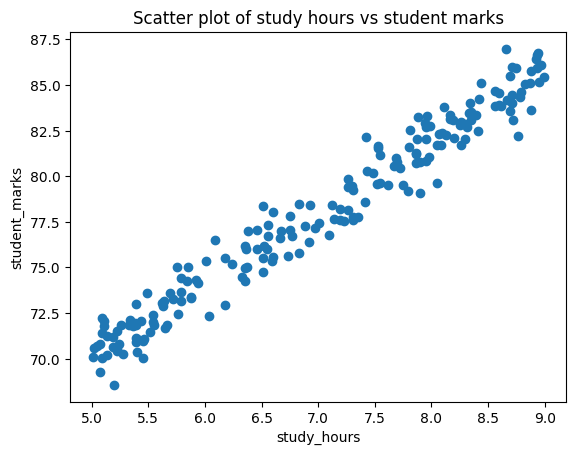

In [13]:
plt.scatter(x=df.study_hours , y=df.student_marks)
plt.xlabel('study_hours')
plt.ylabel('student_marks')
plt.title('Scatter plot of study hours vs student marks')
plt.show()

# Prepare the data for Machine Learning algorthim

In [14]:
# Data Cleaning

In [15]:
df.isnull()

,study_hours,student_marks
0,False,False
1,False,False
2,True,False
3,False,False
4,False,False
...,...,...
195,False,False
196,False,False
197,False,False
198,False,False


In [16]:
df.isnull().sum()

,0
study_hours,5
student_marks,0


In [35]:
df2 =df

In [36]:
df2

,study_hours,student_marks
0,6.830000,78.50
1,6.560000,76.74
2,6.995949,78.68
3,5.670000,71.82
4,8.670000,84.19
...,...,...
195,7.530000,81.67
196,8.560000,84.68
197,8.940000,86.75
198,6.600000,78.05


In [37]:
df2['study_hours']=df2['study_hours'].fillna(np.mean(pd.to_numeric(df2['study_hours'])))

In [38]:
df2

,study_hours,student_marks
0,6.830000,78.50
1,6.560000,76.74
2,6.995949,78.68
3,5.670000,71.82
4,8.670000,84.19
...,...,...
195,7.530000,81.67
196,8.560000,84.68
197,8.940000,86.75
198,6.600000,78.05


In [39]:
df2.isnull().sum()

,0
study_hours,0
student_marks,0


In [41]:
df2.mean()

,0
study_hours,6.995949
student_marks,77.933750


In [42]:
df2.head()

,study_hours,student_marks
0,6.830000,78.50
1,6.560000,76.74
2,6.995949,78.68
3,5.670000,71.82
4,8.670000,84.19


In [22]:
# Split dataset

In [52]:
# X ---matrix
# y---Vector
X =df2.drop('student_marks',axis='columns')
y =df2.drop('study_hours',axis='columns')

print('shape of X =',X.shape)
print('shape of y =',y.shape)

shape of X = (200, 1)
shape of y = (200, 1)


In [44]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test =train_test_split(X,y ,test_size=0.2,random_state=51)

print('shape of X_train =',X_train.shape)
print('shape of X_test =',X_test.shape)
print('shape of y_train =',y_train.shape)
print('shape of X_test =',X_test.shape)


shape of X_train = (160, 1)
shape of X_test = (40, 1)
shape of y_train = (160, 1)
shape of X_test = (40, 1)


# Select Model and train it

In [50]:
# y = m *x +c
from sklearn.linear_model import LinearRegression
lr =LinearRegression()
lr.fit(X_train,y_train)


LinearRegression()

In [34]:
df

,study_hours,student_marks
0,6.830000,78.50
1,6.560000,76.74
2,6.995949,78.68
3,5.670000,71.82
4,8.670000,84.19
...,...,...
195,7.530000,81.67
196,8.560000,84.68
197,8.940000,86.75
198,6.600000,78.05


In [48]:
# coef means--m value
lr.coef_

array([[3.93571802]])

In [51]:
lr.intercept_

array([50.44735504])

In [54]:
m = 3.93
c = 50.44
y =m *5 +c
y


70.09

In [56]:
lr.predict([[4]])[0][0].round(2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(66.19)

In [59]:
y_pred =lr.predict(X_test)
y_pred

array([[83.11381458],
       [78.9025963 ],
       [84.57003024],
       [85.82946001],
       [84.72745896],
       [80.75238377],
       [72.84159055],
       [71.66087515],
       [73.23516235],
       [71.66087515],
       [73.47130543],
       [76.38373677],
       [73.23516235],
       [73.58937697],
       [82.95638585],
       [70.40144538],
       [73.23516235],
       [78.74516758],
       [75.55723598],
       [82.68088559],
       [76.65923703],
       [70.48015974],
       [74.77009238],
       [77.98143645],
       [85.59331693],
       [82.56281405],
       [76.42309395],
       [85.0423164 ],
       [78.39095296],
       [81.38209865],
       [81.73631327],
       [83.15317176],
       [82.20859943],
       [81.10659839],
       [73.58937697],
       [71.1492318 ],
       [71.89701823],
       [81.53952737],
       [72.60544747],
       [71.93637541]])

In [61]:
pd.DataFrame(np.c_[X_test,y_test,y_pred],columns=['study_hours' ,'students_marks_orginal' ,'student_marks_predicter'])

,study_hours,students_marks_orginal,student_marks_predicter
0,8.300000,82.02,83.113815
1,7.230000,77.55,78.902596
2,8.670000,84.19,84.570030
3,8.990000,85.46,85.829460
4,8.710000,84.03,84.727459
5,7.700000,80.81,80.752384
6,5.690000,73.61,72.841591
7,5.390000,70.90,71.660875
8,5.790000,73.14,73.235162
9,5.390000,73.02,71.660875


# Fine-tune Model

In [62]:
lr.score(X_test,y_test)

0.9514124242154466

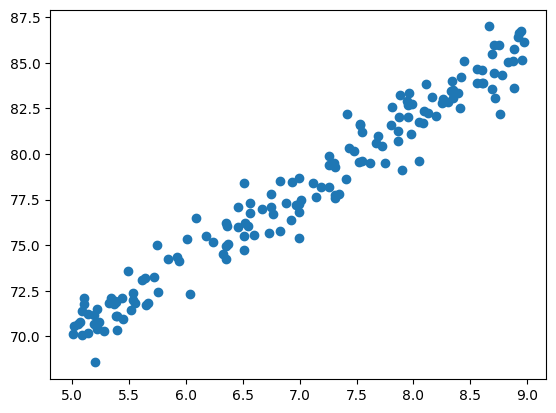

In [63]:
plt.scatter(X_train,y_train)

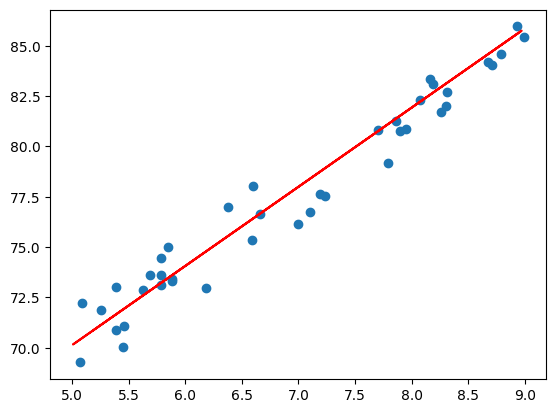

In [65]:
plt.scatter(X_test ,y_test)
plt.plot(X_train,lr.predict(X_train),color ='r')

 # present your solution

 # Save ML Model

In [66]:
import joblib
joblib.dump(lr,'Student_mark_predictor_model.pkl')

['Student_mark_predictor_model.pkl']

In [67]:
model =joblib.load('Student_mark_predictor_model.pkl')

In [69]:
model.predict([[5]])[0][0]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(70.12594512018406)

# Lunch .moniter,and maintain your System